# Análise exploratória: churn de clientes

**Pergunta de negócio:** quais clientes têm mais chance de cancelar o serviço e o que eles têm em comum?

Base pública *Telco Customer Churn* (IBM): 7.043 clientes de uma empresa de telecomunicações, com dados de contrato, serviços contratados, forma de pagamento e se o cliente cancelou no último mês.

In [1]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import pandas as pd

from churn.dados import carregar, NOMES, VALORES

plt.rcParams.update({'figure.figsize': (7, 3), 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e1e0d9', 'axes.axisbelow': True})
AZUL = '#2a78d6'

df = carregar()
print(f'{len(df):,} clientes | taxa de churn: {df.Churn.mean():.1%}')

7,043 clientes | taxa de churn: 26.5%


## 1. Quanto o churn custa

Soma das mensalidades dos clientes que cancelaram, comparada ao faturamento mensal total.

In [2]:
perdida = df.loc[df.Churn == 1, 'MonthlyCharges'].sum()
total = df.MonthlyCharges.sum()
print(f'Receita mensal perdida: US$ {perdida:,.0f} de US$ {total:,.0f} ({perdida / total:.1%})')

Receita mensal perdida: US$ 139,131 de US$ 456,117 (30.5%)


## 2. Taxa de churn por característica

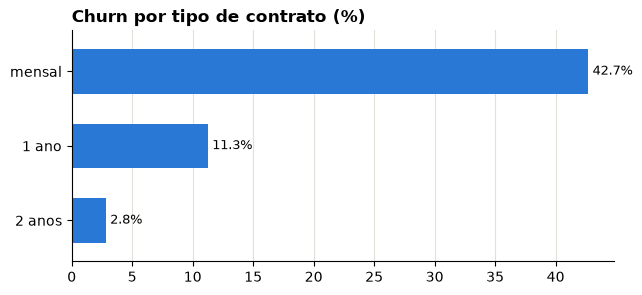

In [3]:
def taxa_por(coluna, ordem=None):
    t = df.groupby(coluna, observed=True).Churn.mean().mul(100)
    t.index = [VALORES.get(str(i), str(i)) for i in t.index]
    if ordem: t = t.reindex(ordem)
    ax = t.plot.barh(color=AZUL, width=0.6)
    ax.set_title(f'Churn por {NOMES.get(coluna, coluna).lower()} (%)', loc='left', fontweight='bold')
    ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3, fontsize=9)
    ax.invert_yaxis(); ax.set_ylabel(''); ax.grid(axis='y', visible=False)
    plt.show()

taxa_por('Contract', ['mensal', '1 ano', '2 anos'])

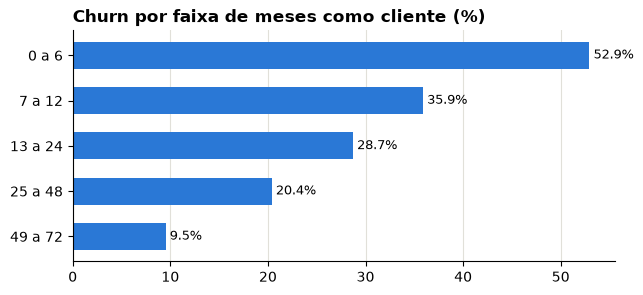

In [4]:
df['Faixa de meses como cliente'] = pd.cut(df.tenure, [-1, 6, 12, 24, 48, 72],
                                          labels=['0 a 6', '7 a 12', '13 a 24', '25 a 48', '49 a 72'])
taxa_por('Faixa de meses como cliente')

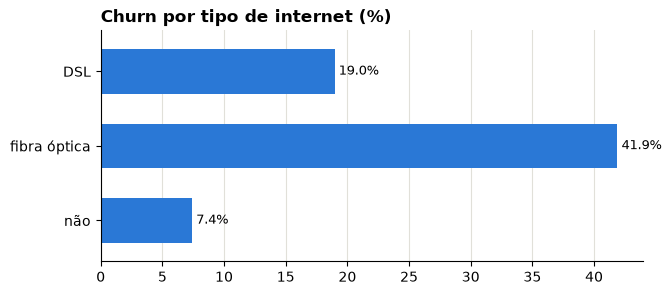

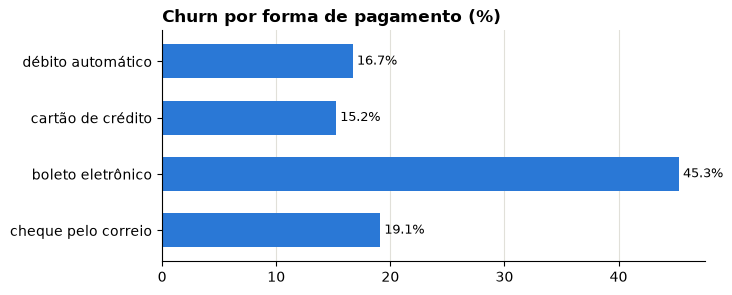

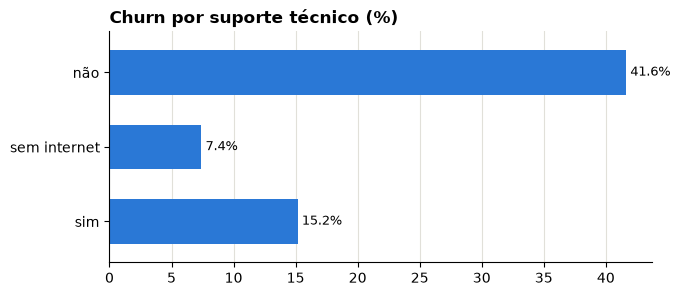

In [5]:
taxa_por('InternetService')
taxa_por('PaymentMethod')
taxa_por('TechSupport')

## 3. Mensalidade de quem sai e de quem fica

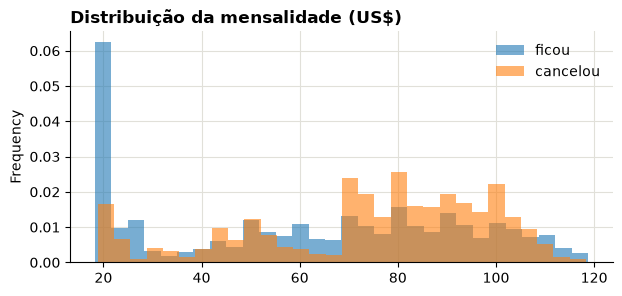

Churn
ficou       64.425
cancelou    79.650
Name: MonthlyCharges, dtype: float64

In [6]:
ax = df.groupby('Churn').MonthlyCharges.plot.hist(bins=30, alpha=0.6, density=True, legend=True)
plt.legend(['ficou', 'cancelou'], frameon=False)
plt.title('Distribuição da mensalidade (US$)', loc='left', fontweight='bold')
plt.show()
df.groupby('Churn').MonthlyCharges.median().rename({0: 'ficou', 1: 'cancelou'})

## Conclusões

- **O churn custa caro:** 26,5% dos clientes cancelaram, levando cerca de **30% da receita mensal**.
- **Contrato é o sinal mais forte:** 42,7% dos clientes com contrato mensal cancelam, contra 11,3% no contrato de 1 ano e 2,8% no de 2 anos.
- **O risco está no começo da relação:** 52,9% dos clientes com até 6 meses cancelam; acima de 4 anos, só 9,5%.
- **Fibra óptica e boleto eletrônico** têm churn de 41,9% e 45,3%, bem acima da média.
- **Suporte técnico e segurança online protegem:** quem não tem esses serviços cancela quase 3 vezes mais (41,6% contra 15,2%).
- **Quem sai paga mais:** mensalidade mediana de US$ 79,65 contra US$ 64,43 de quem fica.

Esses padrões orientam o modelo (`src/churn/treino.py`), que transforma esses sinais em uma probabilidade por cliente e decide quem vale abordar com uma oferta de retenção.